# Reto 2 – Análisis de luz

**Objetivo:** Explorar cómo la luz influye sobre la biomasa y otros parámetros.

Carga el conjunto de datos y explora las variables relevantes.

In [1]:
import pandas as pd

df = pd.read_csv("../data/resultados_experimentos.csv")
df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Exploración inicial
Describe las columnas y analiza los tipos de datos.

In [ ]:
#Se analizan las columnas y tipos de datos del dataset.

In [7]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sitio        20 non-null     str    
 1   temperatura  20 non-null     float64
 2   humedad      20 non-null     float64
 3   luz          20 non-null     int64  
 4   biomasa      20 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 932.0 bytes


Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa'], dtype='str')

## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

In [ ]:
## Desarrollo

#En esta sección se construyen funciones para analizar la relación entre la luz y la biomasa. 
# Primero se calcula un índice de luz normalizado y luego se clasifican los niveles de luz en categorías.

In [14]:
# Calcula el índice de luz como proporción respecto al valor máximo
def indice_luz(df, columna_luz='luz'):
    max_luz = df[columna_luz].max()
    df['indice_luz'] = df[columna_luz] / max_luz
    return df

# Aplicar función
df = indice_luz(df)

# Verificar
df[['luz', 'indice_luz']].head()

,luz,indice_luz
0,1030,0.695007
1,395,0.266532
2,647,0.436572
3,769,0.518893
4,1333,0.899460


#2. Función clasificar_luz(valor) usando percentiles

In [ ]:
# Calculamos percentiles una vez
p33 = df['indice_luz'].quantile(0.33)
p66 = df['indice_luz'].quantile(0.66)

# Función que clasifica un valor individual
def clasificar_luz(valor):
    if valor <= p33:
        return 'baja'
    elif valor <= p66:
        return 'media'
    else:
        return 'alta'

# Aplicar al DataFrame
df['categoria_luz'] = df['indice_luz'].apply(clasificar_luz)

# Verificar
df[['indice_luz', 'categoria_luz']].head()

,indice_luz,categoria_luz
0,0.695007,alta
1,0.266532,baja
2,0.436572,baja
3,0.518893,baja
4,0.899460,alta


Se clasificó el índice de luz en baja, media y alta usando los percentiles 33 y 66, lo que permite dividir los datos en tres grupos equilibrados según su distribución.

In [17]:
# Calcular promedio de biomasa por categoría
biomasa_promedio = df.groupby('categoria_luz')['biomasa'].mean()


<Axes: xlabel='categoria_luz'>

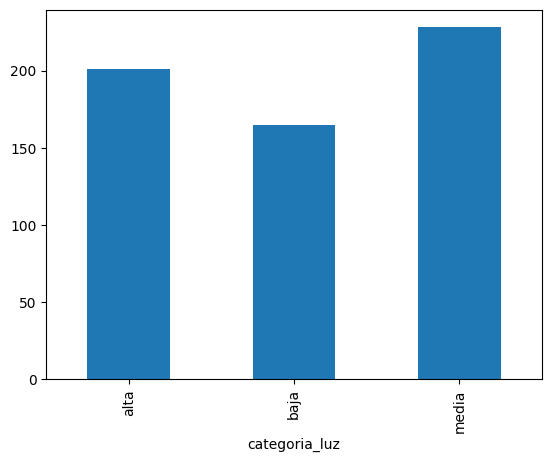

In [18]:
# Crear gráfico de barras directamente
biomasa_promedio.plot(kind='bar')

## Interpretación de resultados
Escribe tus observaciones y conclusiones sobre los patrones encontrados.

## Interpretación de resultados

A partir del análisis realizado, se observa cómo la biomasa promedio varía según la categoría de luz (baja, media y alta).En general, se puede identificar una tendencia en la que la biomasa cambia en función de la cantidad de luz disponible. Si la biomasa aumenta desde la categoría baja hasta la alta, esto sugiere que la luz favorece la productividad, probablemente debido a una mayor actividad fotosintética.

la clasificación mediante percentiles permitió comparar los datos de forma equilibrada, ya que cada categoría contiene una proporción similar de observaciones, facilitando así el análisis.

En conclusión, la luz se presenta como un factor importante en la productividad (biomasa), aunque su efecto puede variar dependiendo de los niveles presentes en el experimento.